In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

In [ ]:
#Loading data_banknote_authentication.txt dataset
cols=['Variance','Skewness','Curtosis','Entropy','Class']
df=pd.read_csv("data_banknote_authentication.txt",names=cols)
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
#Printing description of the dataset
print("Shape:",df.shape)

print("Missing Values:",df.isnull().sum())

print("Statistics:")
print(df.describe())
print(df.info())

Shape: (1372, 5)
Missing Values: Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64
Statistics:
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewn

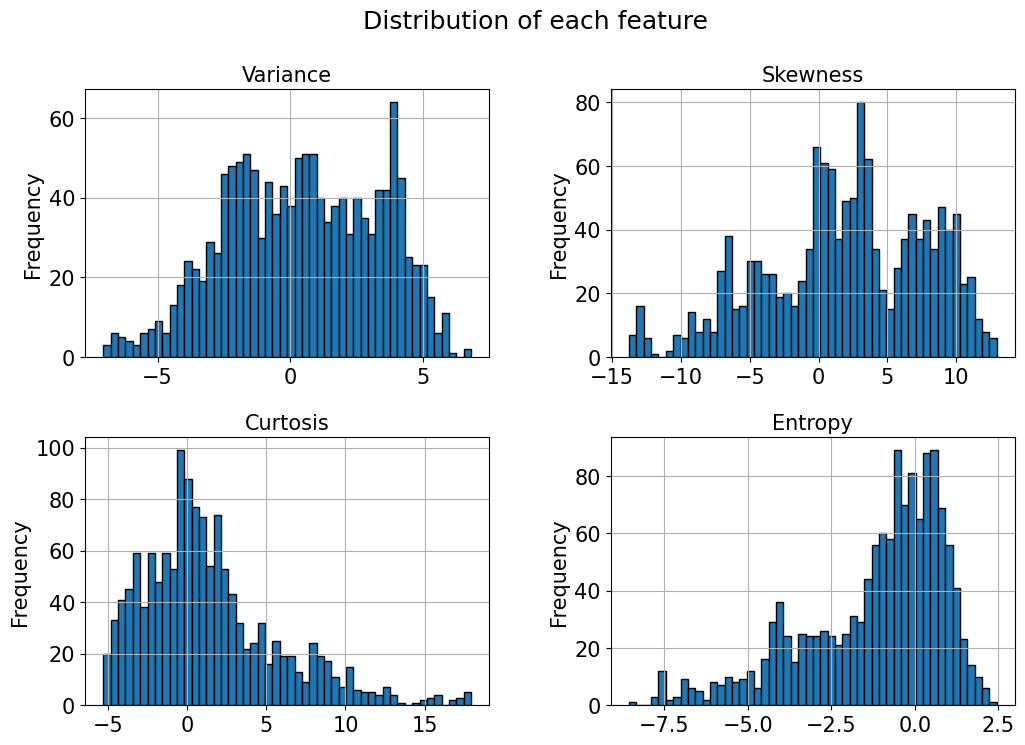

In [ ]:
#Histograms of each feature
axes=df.iloc[:,:4].hist(figsize=(12,8),bins=50,edgecolor='black')
for ax in axes.flatten():
    ax.set_ylabel("Frequency")
plt.suptitle("Distribution of each feature")
plt.savefig("features_histogram.eps",dpi=600)
plt.show()

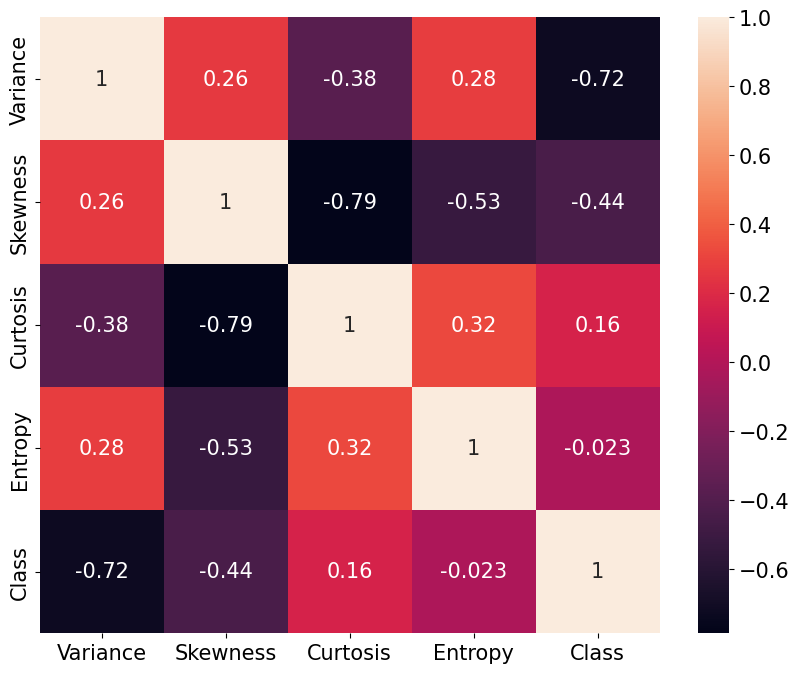

In [ ]:
#Correlation map of features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.savefig("feature_correlation_map.eps",dpi=600)
plt.show()

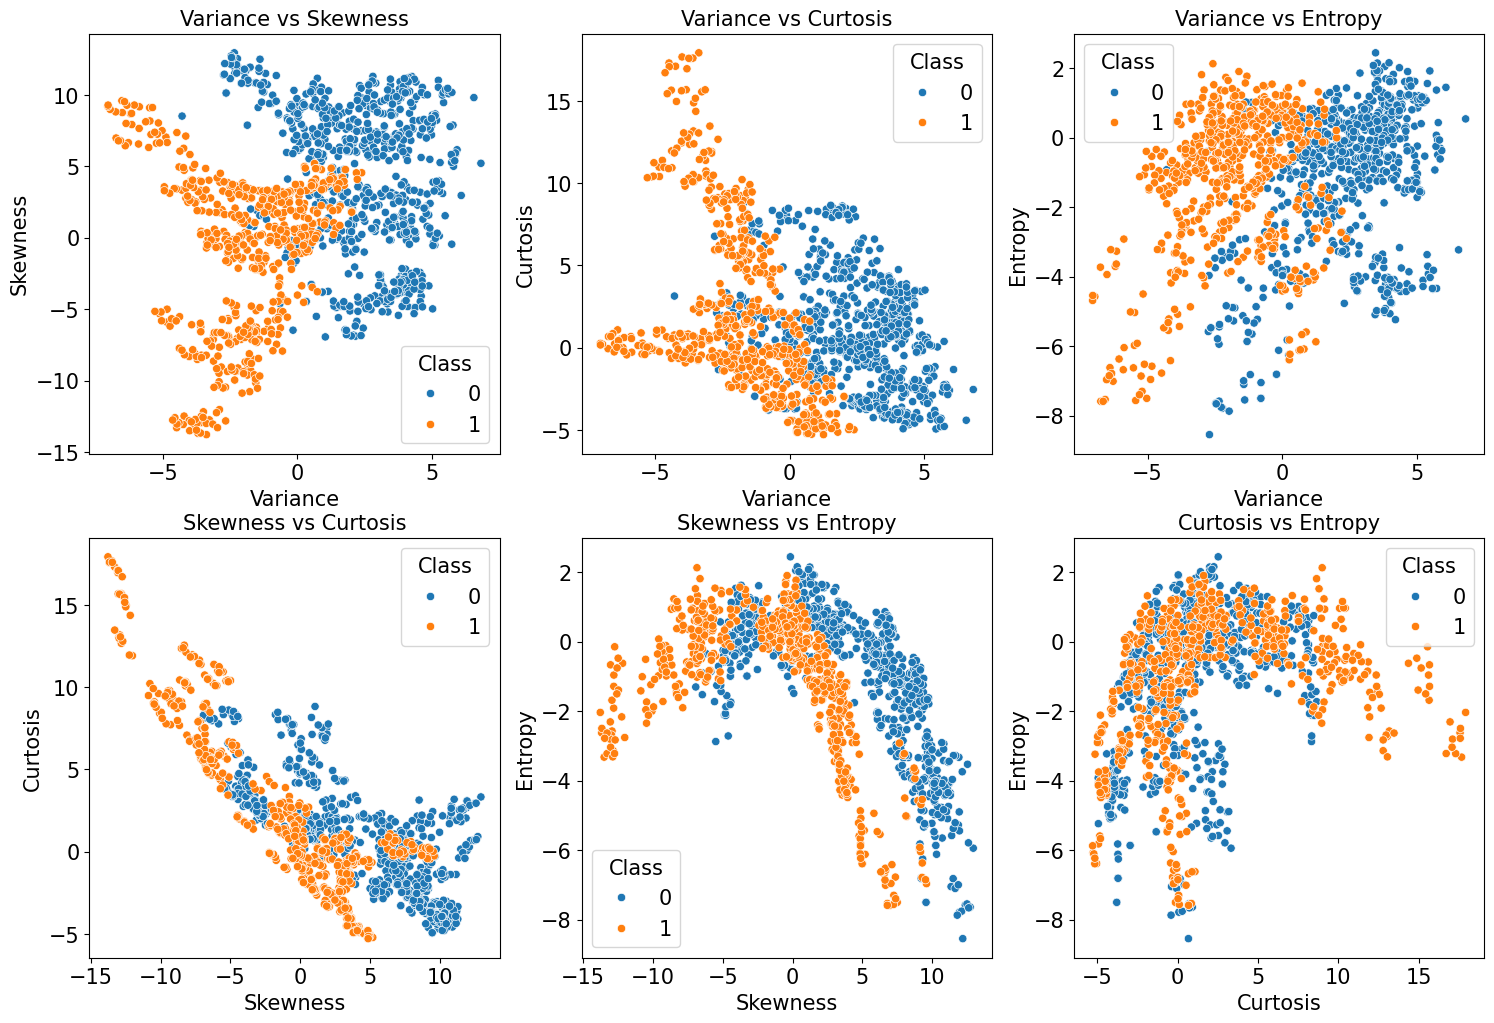

In [ ]:
fig, axes=plt.subplots(2,3,figsize=(18, 12))

#Scatter Plot Variance vs Skewness
sns.scatterplot(x='Variance',y='Skewness', hue='Class',data=df, ax=axes[0,0])
axes[0,0].set_title("Variance vs Skewness")

#Scatter Plot Variance vs Curtosis
sns.scatterplot(x='Variance',y='Curtosis', hue='Class',data=df, ax=axes[0,1])
axes[0,1].set_title("Variance vs Curtosis")

#Scatter Plot Variance vs Entropy
sns.scatterplot(x='Variance',y='Entropy', hue='Class',data=df, ax=axes[0,2])
axes[0,2].set_title("Variance vs Entropy")

#Scatter Plot Skewness vs Curtosis
sns.scatterplot(x='Skewness',y='Curtosis', hue='Class',data=df, ax=axes[1,0])
axes[1,0].set_title("Skewness vs Curtosis")

#Scatter Plot Skewness vs Entropy
sns.scatterplot(x='Skewness',y='Entropy', hue='Class',data=df, ax=axes[1,1])
axes[1,1].set_title("Skewness vs Entropy")

#Scatter Plot Curtosis vs Entropy
sns.scatterplot(x='Curtosis',y='Entropy', hue='Class',data=df, ax=axes[1,2])
axes[1,2].set_title("Curtosis vs Entropy")

plt.savefig("feature_scatter_plot.eps",dpi=600)
plt.show()

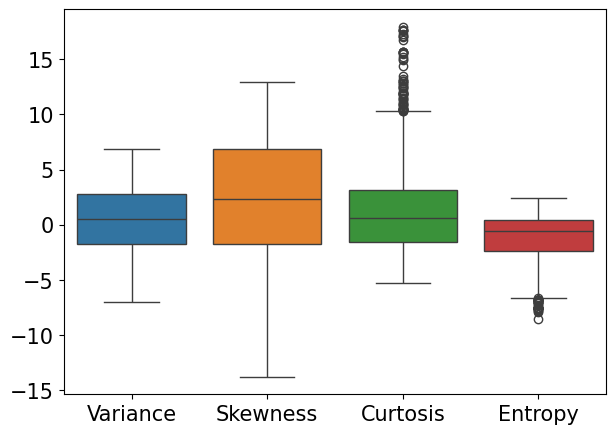

In [ ]:
#Box Plot for each feature
plt.figure(figsize=(7,5))
sns.boxplot(data=df.iloc[:,:4])
plt.savefig("feature_box_plot.eps",dpi=600)
plt.show()

In [ ]:
#Scaling Features
X=df.iloc[:,:4].values
y=df['Class'].values

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(X)

print(X)


[[ 1.12180565  1.14945512 -0.97597007  0.35456135]
 [ 1.44706568  1.06445293 -0.89503626 -0.12876744]
 [ 1.20780971 -0.77735215  0.12221838  0.61807317]
 ...
 [-1.47235682 -2.62164576  3.75901744 -0.75488418]
 [-1.40669251 -1.75647104  2.552043   -0.04315848]
 [-1.04712236 -0.43982168  0.29861555  1.1364645 ]]


In [ ]:
#Train-Test-Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (1097, 4)
X_test shape: (275, 4)
y_train shape: (1097,)
y_test shape: (275,)


In [ ]:

#Step function
def step(z):
  if z>=0:
    return 1
  else:
    return 0

#Forward Propogation and Perceptron Learning Rule
def perceptron(x,y,lr):
  #Initializing weights, bias, learning rate, epochs
  weights=np.zeros(x.shape[1])
  bias=0
  epochs=100
  error=[]
  weights_hist=[]
  bias_hist=[]

  for epoch in range(epochs):
    err_cnt=0
    for i in range(len(x)):
      z=np.dot(x[i],weights)+bias
      pred=step(z)

      weights+=lr*(y[i]-pred)*x[i]
      bias+=lr*(y[i]-pred)

      if pred!=y[i]:
        err_cnt+=1

    error.append(err_cnt)
    weights_hist.append(weights.copy())
    bias_hist.append(bias)

    print("Epoch Number:",epoch+1)
    print("Misclassified samples:",err_cnt)
    print("Updated weights:",weights)
    print("Updated bias:",bias,"\n")

  return weights,bias,error,weights_hist,bias_hist


In [ ]:
#Training perceptron with learning rate=0.1
weight,bias,error,weights_hist,bias_hist=perceptron(X_train,y_train,0.1)

Epoch Number: 1
Misclassified samples: 47
Updated weights: [-0.72536882 -0.64862657 -0.6445982   0.00198583]
Updated bias: -0.30000000000000004 

Epoch Number: 2
Misclassified samples: 26
Updated weights: [-0.82170146 -0.93801992 -0.51493537 -0.05182421]
Updated bias: -0.30000000000000004 

Epoch Number: 3
Misclassified samples: 34
Updated weights: [-0.94676415 -0.91400307 -0.89055425 -0.09564681]
Updated bias: -0.5 

Epoch Number: 4
Misclassified samples: 23
Updated weights: [-1.10744834 -0.95808784 -1.06306876 -0.13124217]
Updated bias: -0.4 

Epoch Number: 5
Misclassified samples: 27
Updated weights: [-1.30963863 -1.21795809 -0.91128277 -0.08770651]
Updated bias: -0.5 

Epoch Number: 6
Misclassified samples: 25
Updated weights: [-1.39534094 -1.28430161 -1.04881726 -0.06690708]
Updated bias: -0.4 

Epoch Number: 7
Misclassified samples: 19
Updated weights: [-1.35269696 -1.4036924  -1.05268576 -0.05156919]
Updated bias: -0.5 

Epoch Number: 8
Misclassified samples: 19
Updated weights:

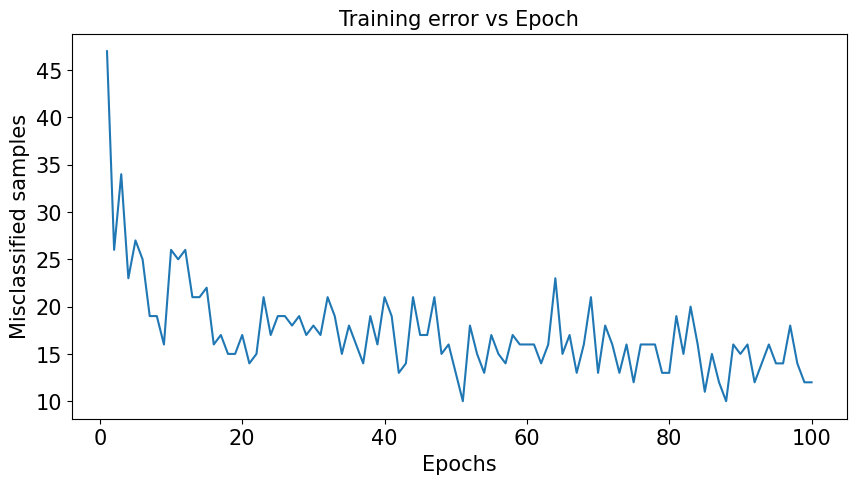

In [ ]:
#Training Error vs Epoch Plot

plt.figure(figsize=(10,5))
plt.plot(range(1,101),error)

plt.xlabel("Epochs")
plt.ylabel("Misclassified samples")
plt.title("Training error vs Epoch")
plt.savefig("training_error_vs_epoch.eps",dpi=600)
plt.show()



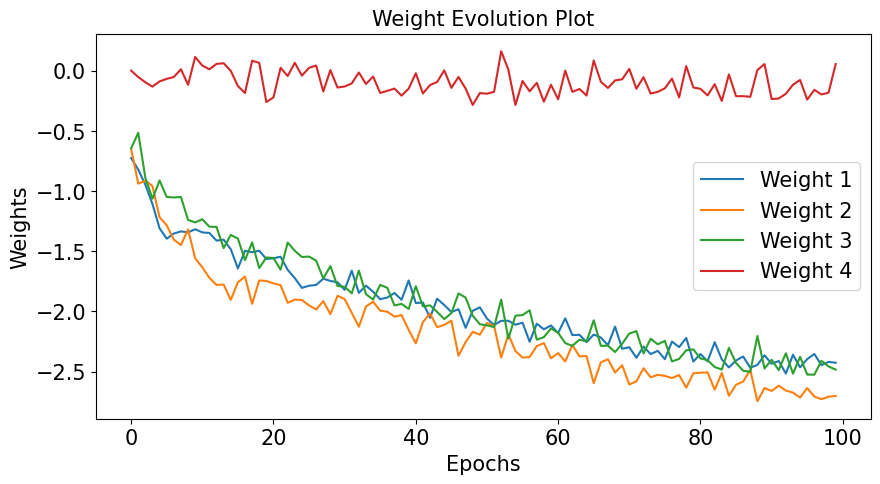

In [ ]:
#Weight Evolution Plot
weights_hist=np.array(weights_hist)

plt.figure(figsize=(10,5))
for i in range (weights_hist.shape[1]):
  plt.plot(weights_hist[:,i],label=f"Weight {i+1}")

plt.xlabel("Epochs")
plt.ylabel("Weights")
plt.title("Weight Evolution Plot")
plt.legend()
plt.savefig("weight_evolution_plot.eps",dpi=600)
plt.show()



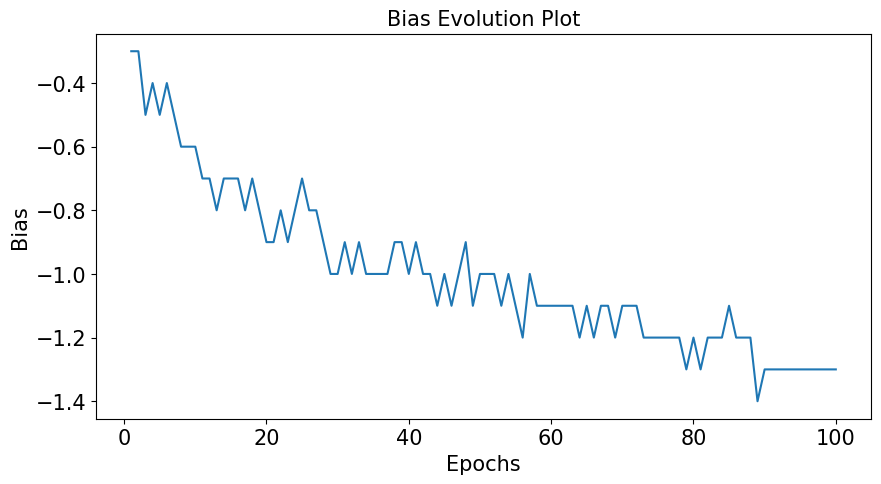

In [ ]:
#Bias Evolution Plot

plt.figure(figsize=(10,5))
plt.plot(range(1,101),bias_hist)
plt.xlabel("Epochs")
plt.ylabel("Bias")
plt.title("Bias Evolution Plot")
plt.savefig("bias_evolution_plot.eps",dpi=600)
plt.show()

Epoch Number: 1
Misclassified samples: 47
Updated weights: [-7.25368818e-03 -6.48626567e-03 -6.44598197e-03  1.98583469e-05]
Updated bias: -0.003 

Epoch Number: 2
Misclassified samples: 26
Updated weights: [-0.00821701 -0.0093802  -0.00514935 -0.00051824]
Updated bias: -0.003 

Epoch Number: 3
Misclassified samples: 34
Updated weights: [-0.00946764 -0.00914003 -0.00890554 -0.00095647]
Updated bias: -0.005 

Epoch Number: 4
Misclassified samples: 23
Updated weights: [-0.01107448 -0.00958088 -0.01063069 -0.00131242]
Updated bias: -0.004 

Epoch Number: 5
Misclassified samples: 27
Updated weights: [-0.01309639 -0.01217958 -0.00911283 -0.00087707]
Updated bias: -0.005 

Epoch Number: 6
Misclassified samples: 25
Updated weights: [-0.01395341 -0.01284302 -0.01048817 -0.00066907]
Updated bias: -0.004 

Epoch Number: 7
Misclassified samples: 19
Updated weights: [-0.01352697 -0.01403692 -0.01052686 -0.00051569]
Updated bias: -0.005 

Epoch Number: 8
Misclassified samples: 19
Updated weights: [

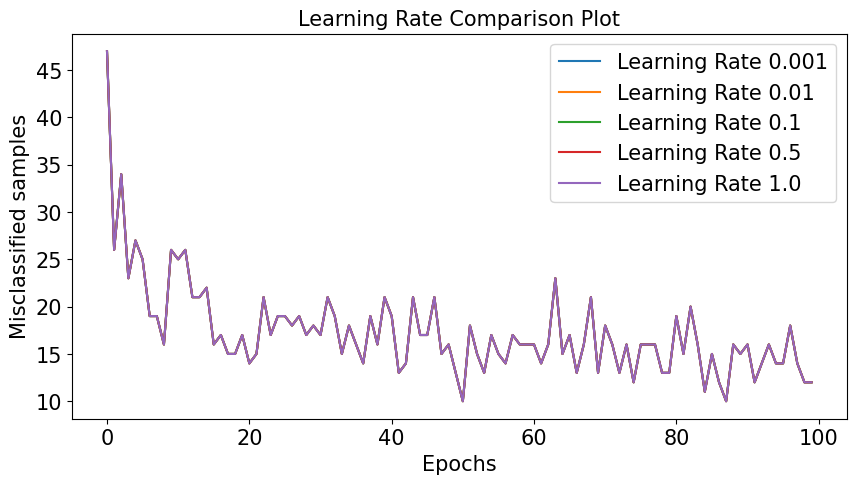

In [ ]:
#Learning Rate Comparison Plot
lr=[0.001,0.01,0.1,0.5,1.0]
plt.figure(figsize=(10,5))
for i in lr:
  w,b,e,wh,bh=perceptron(X_train,y_train,i)
  plt.plot(e,label=f"Learning Rate {i}")

plt.xlabel("Epochs")
plt.ylabel("Misclassified samples")
plt.title("Learning Rate Comparison Plot")
plt.legend()
plt.savefig("learning_rate_comparison_plot.eps",dpi=600)
plt.show()


In [ ]:
#Prediction for test data
pred=[]
for i in range(len(X_test)):
  z=np.dot(X_test[i],weight)+bias
  pred.append(step(z))

pred=np.array(pred)

#Model Evaluation - Accuracy, Precision, Recall Score, F1 Score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

acc=accuracy_score(y_test,pred)
p=precision_score(y_test,pred)
r=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
print(f"""
Accuracy: {acc}
Precision: {p}
Recall: {r}
F1 Score: {f1}
      """)


Accuracy: 0.9854545454545455
Precision: 0.984251968503937
Recall: 0.984251968503937
F1 Score: 0.984251968503937
      


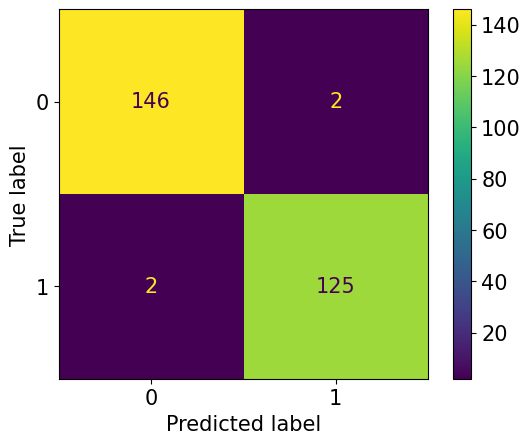

[[146   2]
 [  2 125]]


In [ ]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot()
plt.savefig("confusion_matrix.eps",dpi=600)
plt.show()
print(cm)